# Préparation des données cinénique enzymatique - détermination de Km et Vmax

In [1]:
import random
random.seed(123)

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def vitesse_michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)

def calcule_cinetique_exp(S_0, Vmax, Km, pas_temps, nombre_points):
    dt = pas_temps
    # On initalise le premier temps à 0 (le début de la simulation).
    temps = [0]
    # On initiliase la première concentration de substrat avec S_0,
    # c'est-à-dire la concentration en susbrtrat au début de l'expérience.
    concentrations_substrat = [S_0]
    # On initialise la première concentration en produit à 0,
    # car il n'y a pas de produit au début de la cinétique.
    concentrations_produit = [0]
    # Pour chaque point, le temps avance de dt.
    # On calcule à chaque fois le nouveau temps, la nouvelle concentration en susbtrat
    # et la nouvelle constration en produit
    for point in range(0, nombre_points):
        temps.append(temps[-1] + dt)
        v = vitesse_michaelis_menten(concentrations_substrat[-1], Vmax, Km)
        concentrations_substrat.append(concentrations_substrat[-1] - v*dt)
        concentrations_produit.append(concentrations_produit[-1] + v*dt)
    # Add random noise to simulate experimental values.
    for index in range(len(temps)):
        concentrations_substrat[index] *= random.gauss(1, 1/220)
        concentrations_produit[index] *= random.gauss(1, 1/220)
    return temps, concentrations_substrat, concentrations_produit

In [3]:
Vmax = 3.5e-4 # µM/min
Km = 3e-4 # M

S0_exp = [Km/3, Km/1.2, Km*1.5, Km*2, Km*4, Km*8, Km*10, Km*30, Km*60, Km*100]
conditions = []
for num, S0 in enumerate(S0_exp, start=1):
    print(f"| {num:9d} | ${S0:.2e}$ |")
    conditions.append(
        {"S0": S0, "name": f"exp{num}"}
    )
for S0 in S0_exp:
    print(f"{S0:.2e}", end=", ")

|         1 | $1.00e-04$ |
|         2 | $2.50e-04$ |
|         3 | $4.50e-04$ |
|         4 | $6.00e-04$ |
|         5 | $1.20e-03$ |
|         6 | $2.40e-03$ |
|         7 | $3.00e-03$ |
|         8 | $9.00e-03$ |
|         9 | $1.80e-02$ |
|        10 | $3.00e-02$ |
1.00e-04, 2.50e-04, 4.50e-04, 6.00e-04, 1.20e-03, 2.40e-03, 3.00e-03, 9.00e-03, 1.80e-02, 3.00e-02, 

In [4]:
for index, condition in enumerate(conditions):
    temps, _, produit = calcule_cinetique_exp(condition["S0"], Vmax, Km, 0.25, 60)
    conditions[index]["temps"] = temps[1:]
    conditions[index]["produit"] = produit[1:]
    with  open(f"{conditions[index]['name']}.txt", "w") as f_out:
        for data in zip(conditions[index]["temps"], conditions[index]["produit"]):
            f_out.write(f"{data[0]:.2f},{data[1]:.3e}\n")

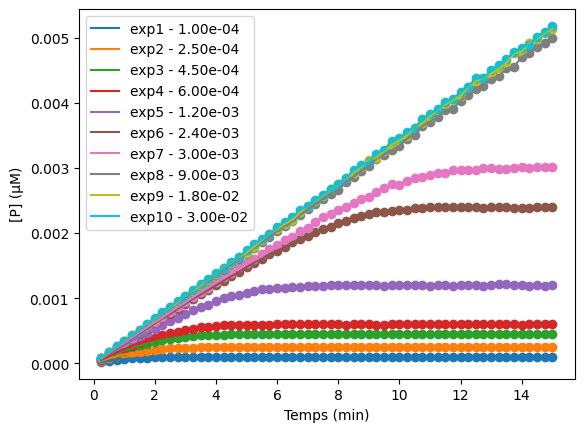

In [5]:
fig, ax = plt.subplots()
ax.set_xlabel("Temps (min)")
ax.set_ylabel("[P] (µM)")
for condition in conditions:
    ax.plot(condition["temps"], condition["produit"], label=f"{condition['name']} - {condition['S0']:.2e}")
    ax.scatter(condition["temps"], condition["produit"])
ax.legend()
plt.show()

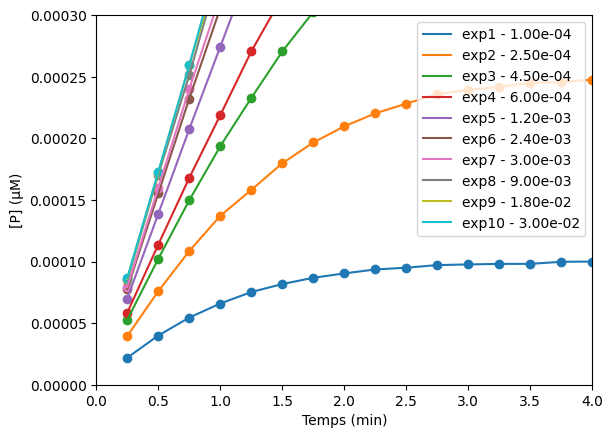

In [6]:
fig, ax = plt.subplots()
ax.set_xlabel("Temps (min)")
ax.set_ylabel("[P] (µM)")
for condition in conditions:
    ax.plot(condition["temps"], condition["produit"], label=f"{condition['name']} - {condition['S0']:.2e}")
    ax.scatter(condition["temps"], condition["produit"])
ax.set_xlim(0, 4)
ax.set_ylim(0, 3e-4)
ax.legend()
plt.show()